# Active Contours (Snakes): intuition first

A snake is a **closed curve** that moves to reduce an energy.

We write the evolving curve as

$$
C(s,t) = (x(s,t), y(s,t)), \qquad s \in [0,1].
$$

A simple way to think about the snake energy is

$$
E(C) = E_{\mathrm{ext}}(C) + \alpha E_1(C) + \beta E_2(C).
$$

Here:

- $E_{\mathrm{ext}}$: pulls the curve toward image features ( We use gradient of an image or brightness-based energy or both. )
- $E_1$: first-derivative term, called **tension**
- $E_2$: second-derivative term, called **rigidity** or **bending regularity**

For a discrete closed curve with points $c_0, \dots, c_{N-1}$, a simple model is

$$
E(c) = E_{\mathrm{image}}(c)
+ \frac{\alpha}{2} \sum_i \|c_{i+1} - c_i\|^2
+ \frac{\beta}{2} \sum_i \|c_{i+1} - 2c_i + c_{i-1}\|^2.
$$

We will use a standard implementation from `skimage.segmentation.active_contour`.

The teaching goal is simple:

1. external/image energy only
2. external energy + first-derivative tension
3. external energy + first-derivative tension + second-derivative rigidity

and then compare what each added term changes.

In [89]:
# ============================================================
# Parameters — edit here to explore different configurations
# ============================================================

# Image
IMG_SIZE      = 160    # grid side length (pixels)
DISK_RADIUS   = 26     # radius of the bright disk
BLUR_SIGMA    = 2.5    # Gaussian blur applied before running the snake

# Initial contour
N_CONTOUR_PTS = 140    # number of control points on the initial snake
INIT_RADIUS   = 35     # mean radius of the wavy starting contour

# Shared snake settings
TAKE_AT  = (0, 40, 80, 160, 240, 320)   # iteration steps to snapshot
W_LINE   = 0.0   # weight for brightness attraction (0 = off)
W_EDGE   = 4.0   # weight for edge-based attraction

# Experiment 1: external energy only
EXP1_ALPHA, EXP1_BETA, EXP1_GAMMA, EXP1_MAX_PX = 0.0,   0.0,  0.05, 1.5

# Experiment 2: + first-derivative (tension)
EXP2_ALPHA, EXP2_BETA, EXP2_GAMMA, EXP2_MAX_PX = 0.015, 0.0,  0.05, 1.5

# Experiment 3: + second-derivative (rigidity)
EXP3_ALPHA, EXP3_BETA, EXP3_GAMMA, EXP3_MAX_PX = 0.015, 1.2,  0.02, 0.8


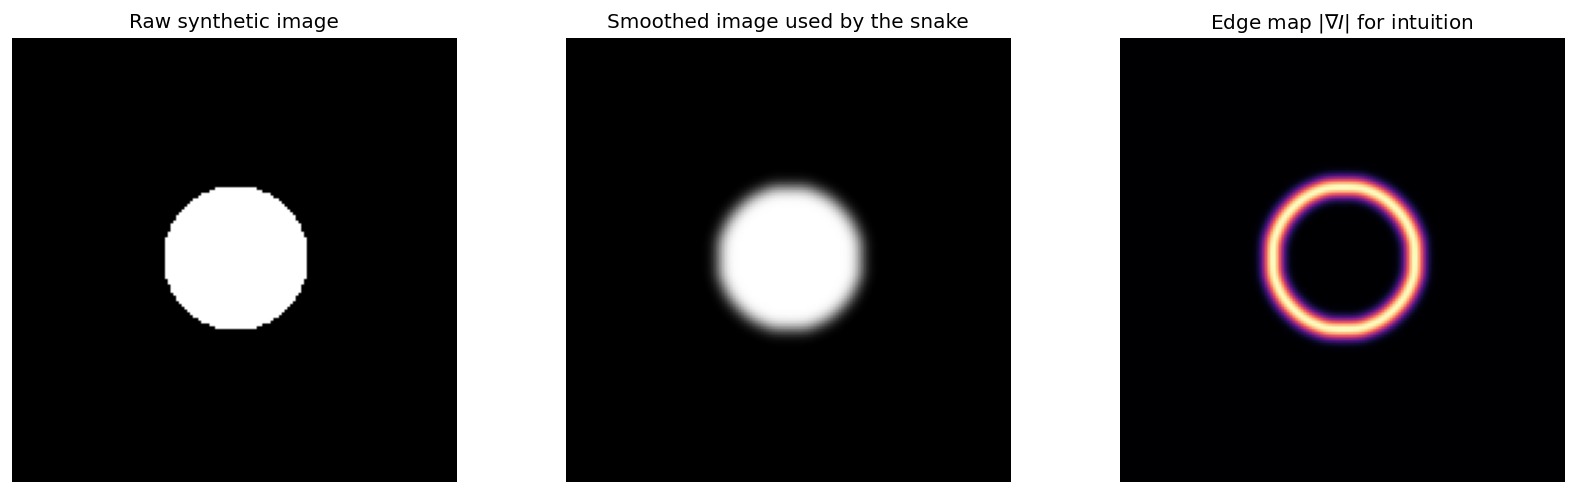

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import disk
from skimage.filters import gaussian, sobel
from skimage.segmentation import active_contour

plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

# ------------------------------------------------------------
# Synthetic image: bright disk on dark background
# ------------------------------------------------------------
n = IMG_SIZE
center_rc = np.array([n / 2, n / 2])  # row, col

raw_image = np.zeros((n, n), dtype=float)
rr, cc = disk((int(center_rc[0]), int(center_rc[1])), DISK_RADIUS, shape=raw_image.shape)
raw_image[rr, cc] = 1.0

# The snake sees a smoothed image so the attraction basin is wider.
image = gaussian(raw_image, sigma=BLUR_SIGMA, preserve_range=True)
edge_map = sobel(image)


def plot_snake(ax, snake, **kwargs):
    snake_closed = np.vstack([snake, snake[0]])
    ax.plot(snake_closed[:, 1], snake_closed[:, 0], **kwargs)


def run_active_contour_snapshots(image, init_snake, take_at, **kwargs):
    """Run active_contour in chunks so we can keep intermediate snapshots."""
    snake = init_snake.copy()
    snapshots = [(0, snake.copy())]
    previous = 0
    for target in take_at[1:]:
        snake = active_contour(
            image,
            snake,
            max_num_iter=target - previous,
            convergence=0.0,
            boundary_condition='periodic',
            **kwargs,
        )
        snapshots.append((target, snake.copy()))
        previous = target
    return snapshots


def plot_snapshots(title, snapshots):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image, origin='lower')
    colors = plt.cm.Blues(np.linspace(0.35, 1.0, len(snapshots)))
    for color, (step, snake) in zip(colors, snapshots):
        plot_snake(ax, snake, color=color, lw=2, label=f'step {step}')
    final_snake = snapshots[-1][1]
    ax.scatter(final_snake[:, 1], final_snake[:, 0], s=9, color='crimson', zorder=3)
    ax.set_title(title)
    ax.set_axis_off()
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].imshow(raw_image, origin='lower')
axes[0].set_title('Raw synthetic image')
axes[1].imshow(image, origin='lower')
axes[1].set_title('Smoothed image used by the snake')
axes[2].imshow(edge_map, origin='lower', cmap='magma')
axes[2].set_title(r'Edge map $|\nabla I|$ for intuition')
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()


**Important parameters in the setup**

- `gaussian(..., sigma=2.5)`: this smooths the disk edge. A larger `sigma` gives a broader, softer edge and usually a wider attraction basin.
- `sobel(image)`: this is only for visualization here. It lets us see where strong edges live.
- `active_contour` works with snake points in `(row, col)` order, so plotting uses `(col, row)` on the axes.
- `run_active_contour_snapshots(...)`: `active_contour` returns only the final snake, so we call it in chunks to record intermediate contours.

## Initial contour

We use the **same closed contour** in all three experiments.

It starts outside the object and it has small wiggles on purpose. That makes it easier to feel what the regularization terms are doing.

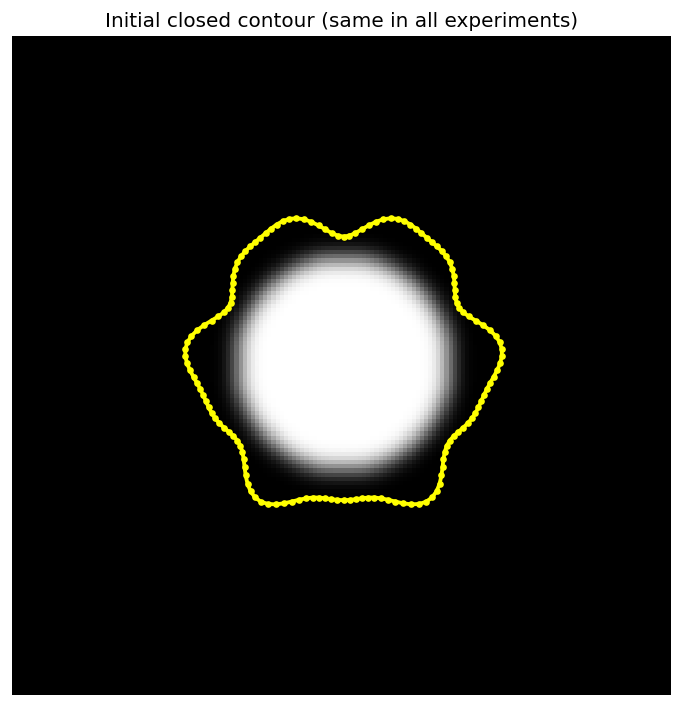

In [91]:
theta = np.linspace(0, 2 * np.pi, N_CONTOUR_PTS, endpoint=False)
radius = INIT_RADIUS + 3.0 * np.cos(6 * theta) + 1.2 * np.sin(11 * theta)

# active_contour expects points in (row, col) order
init_snake = np.column_stack([
    center_rc[0] + radius * np.sin(theta),
    center_rc[1] + radius * np.cos(theta),
])

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, origin='lower')
plot_snake(ax, init_snake, color='yellow', lw=2.3)
ax.scatter(init_snake[:, 1], init_snake[:, 0], s=9, color='yellow')
ax.set_title('Initial closed contour (same in all experiments)')
ax.set_axis_off()
plt.tight_layout()
plt.show()


## Experiment 1: only external/image energy

We now isolate the image term by setting

$$
\alpha = 0, \qquad \beta = 0.
$$

So each sampled point is driven only by the image attraction.

What we want to see:

- the contour does move toward the boundary
- but the points do not regularize each other
- spacing and shape quality can become poor
- the result can look jagged or uneven

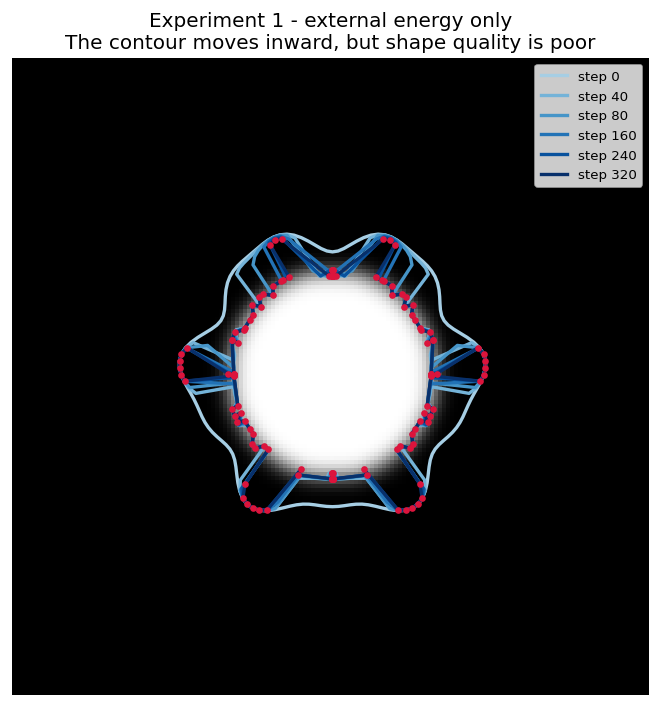

In [92]:
snap_ext = run_active_contour_snapshots(
    image,
    init_snake,
    take_at=TAKE_AT,
    alpha=EXP1_ALPHA,
    beta=EXP1_BETA,
    w_line=W_LINE,
    w_edge=W_EDGE,
    gamma=EXP1_GAMMA,
    max_px_move=EXP1_MAX_PX,
)

plot_snapshots(
    'Experiment 1 - external energy only\nThe contour moves inward, but shape quality is poor',
    snap_ext,
)


**Important `active_contour` parameters in Experiment 1**

- `w_line=0.0`: we turn off attraction to brightness itself. The snake is not trying to sit in bright regions.
- `w_edge=4.0`: this multiplies the **edge-based external term**. It is not a multiplier for the whole snake energy, only for the edge attraction part. Larger values make edges matter more.
- `gamma=0.05`: explicit step size. Larger `gamma` means more aggressive motion each iteration.
- `max_px_move=1.5`: hard cap on how many pixels a point can move in one iteration. This helps keep the update stable.
- `max_num_iter`: in our helper, this is the number of iterations in each chunk between snapshots.
- `convergence=0.0`: we disable early stopping inside each chunk so the snapshot counts are predictable.
- `boundary_condition='periodic'`: this makes the snake closed.

## Experiment 2: add the first-derivative term

Now we add **tension** through the first-derivative term.

Intuition:

- neighboring points start to pull on each other
- the contour becomes more coherent
- short-scale irregularity is reduced

But tension also encourages the curve to shorten, so it can still shrink too much.

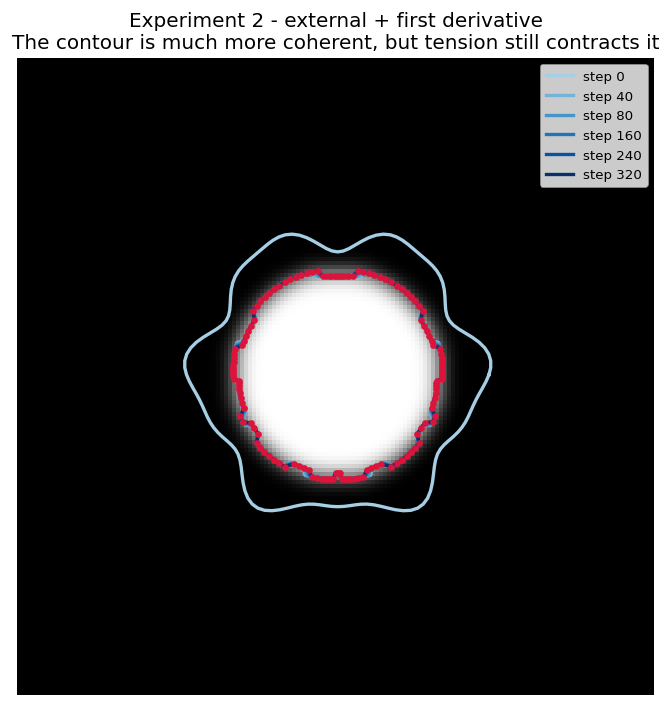

In [93]:
snap_tension = run_active_contour_snapshots(
    image,
    init_snake,
    take_at=TAKE_AT,
    alpha=EXP2_ALPHA,
    beta=EXP2_BETA,
    w_line=W_LINE,
    w_edge=W_EDGE,
    gamma=EXP2_GAMMA,
    max_px_move=EXP2_MAX_PX,
)

plot_snapshots(
    'Experiment 2 - external + first derivative\nThe contour is much more coherent, but tension still contracts it',
    snap_tension,
)


**Important new parameter in Experiment 2**

- `alpha=0.015`: this is the tension weight. Higher `alpha` makes the snake contract faster and couples neighboring points more strongly.

So `alpha` improves coherence, but it can also make the snake shrink inward more aggressively.

## Experiment 3: add the second-derivative term

Now we also add **rigidity** through the second-derivative term.

This term penalizes rapid changes of direction, so it resists kinks and high-curvature oscillations.

This is different from tension:

- tension helps keep points together
- rigidity helps keep curvature smooth

That is why the classical snake uses both terms.

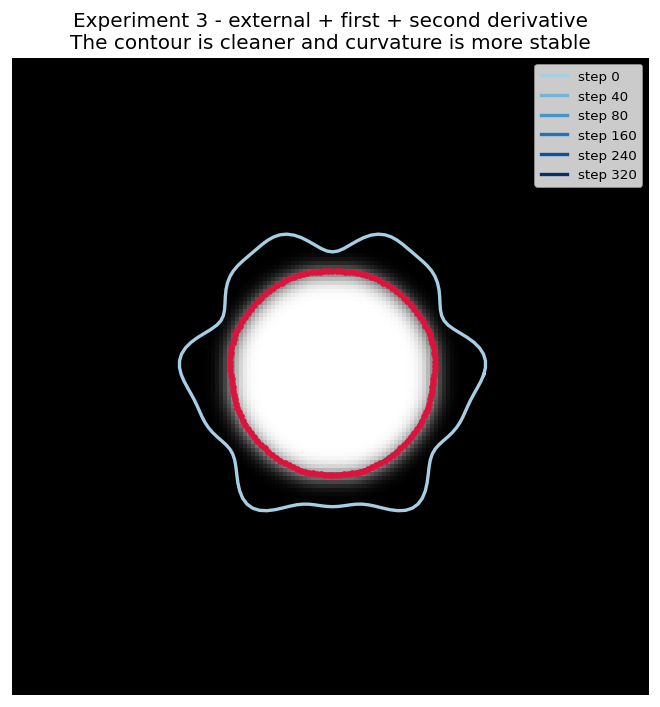

In [94]:
snap_full = run_active_contour_snapshots(
    image,
    init_snake,
    take_at=TAKE_AT,
    alpha=EXP3_ALPHA,
    beta=EXP3_BETA,
    w_line=W_LINE,
    w_edge=W_EDGE,
    gamma=EXP3_GAMMA,
    max_px_move=EXP3_MAX_PX,
)

plot_snapshots(
    'Experiment 3 - external + first + second derivative\nThe contour is cleaner and curvature is more stable',
    snap_full,
)


**Important new parameter in Experiment 3**

- `beta=1.2`: this is the rigidity weight. Higher `beta` makes the snake smoother and less willing to bend sharply.
- `gamma=0.02`: we reduce the step size a bit when rigidity is active so the evolution stays gentle.
- `max_px_move=0.8`: we also reduce the move cap to keep the motion controlled.

So `beta` is not redundant with `alpha`:

- `alpha` mainly controls tension / contraction
- `beta` mainly controls bending smoothness

## Final comparison

The dashed white curve is the **same initial contour** in all three panels.
The colored curve is the final result.

This is the main picture to remember:

1. external only: the contour moves, but looks uneven
2. + first derivative: much more coherent, but still contraction-heavy
3. + first + second derivative: smoother curvature and a cleaner final snake

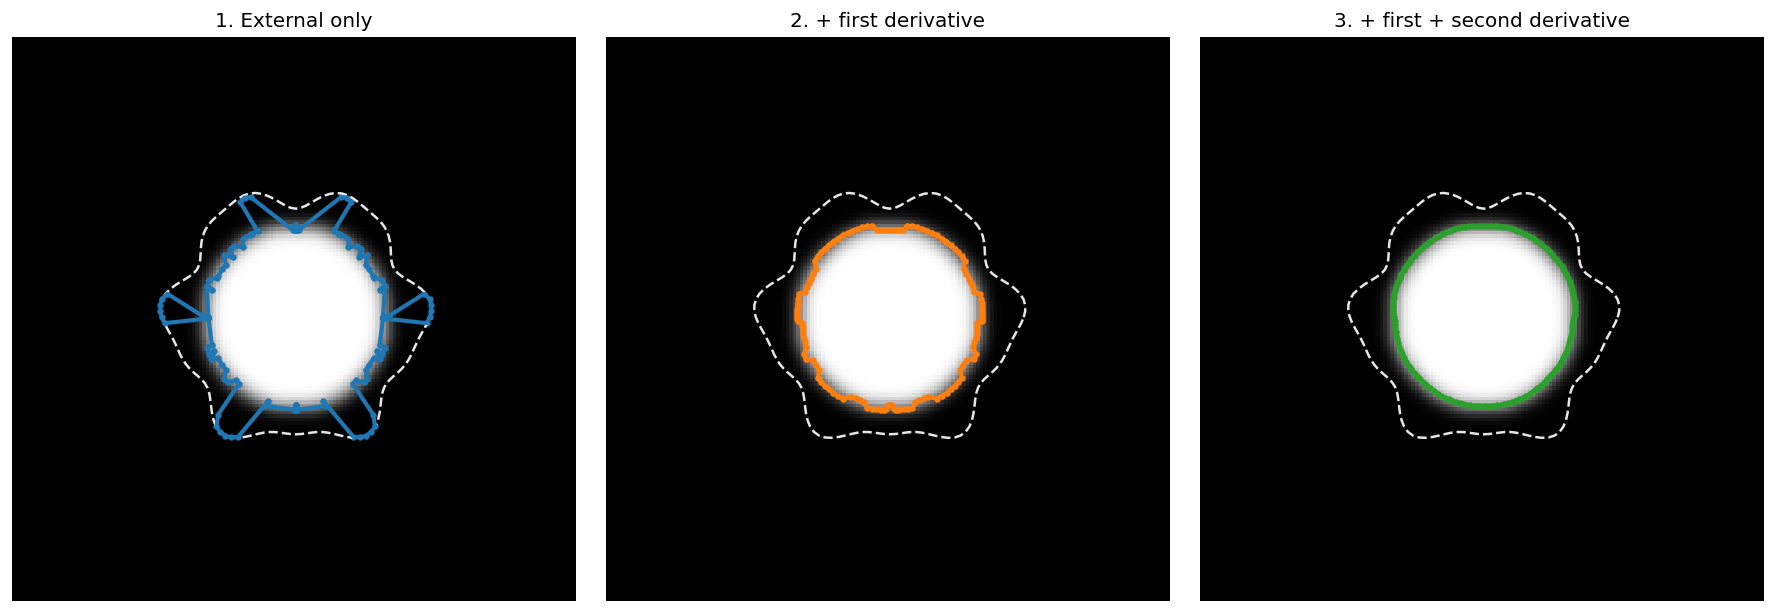

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
cases = [
    ('1. External only', snap_ext[-1][1], 'tab:blue'),
    ('2. + first derivative', snap_tension[-1][1], 'tab:orange'),
    ('3. + first + second derivative', snap_full[-1][1], 'tab:green'),
]

for ax, (title, snake, color) in zip(axes, cases):
    ax.imshow(image, origin='lower')
    plot_snake(ax, init_snake, color='white', lw=1.5, ls='--', alpha=0.9)
    plot_snake(ax, snake, color=color, lw=2.5)
    ax.scatter(snake[:, 1], snake[:, 0], s=8, color=color)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()


## Conclusion

The snake is an energy-minimizing curve.

- The **external/image energy** tells the contour where the object boundary is.
- The **first-derivative term** gives **tension**: neighboring points pull on each other and the curve becomes more coherent.
- The **second-derivative term** gives **bending regularity**: the snake resists kinks and high-curvature oscillations.

So the three ingredients play different roles:

- external term: attraction to image structure
- first derivative: stretching / contraction control
- second derivative: bending / curvature control

That is the core intuition behind the classical active contour model.